In [56]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit, njit

plt.rcParams["figure.dpi"] = 300

In [31]:
@njit
def uniform():
    return np.random.uniform(np.nextafter(0, 1), 1)

@njit
def sim(lam, p, sim_time):
    t = 0.0
    n = 0

    while True:
        u1 = uniform()
        u2 = uniform()

        dt = -np.log(u1) / lam

        if t + dt > sim_time:
            break

        t += dt

        n += (u2 < p)

    return n

sim(2, 0.5, 10_000)

def estimate(lam, p, sim_time, iter):
    n = 0
    for _ in range(iter):
        n += sim(lam, p, sim_time)
    return n / (sim_time * iter)

In [34]:
estimate(2, 0.5, 10_000, 1000)

0.9997273

In [64]:
x = np.linspace(0, 1, 5)
y = [estimate(2, xi, 500, 20) for xi in x]

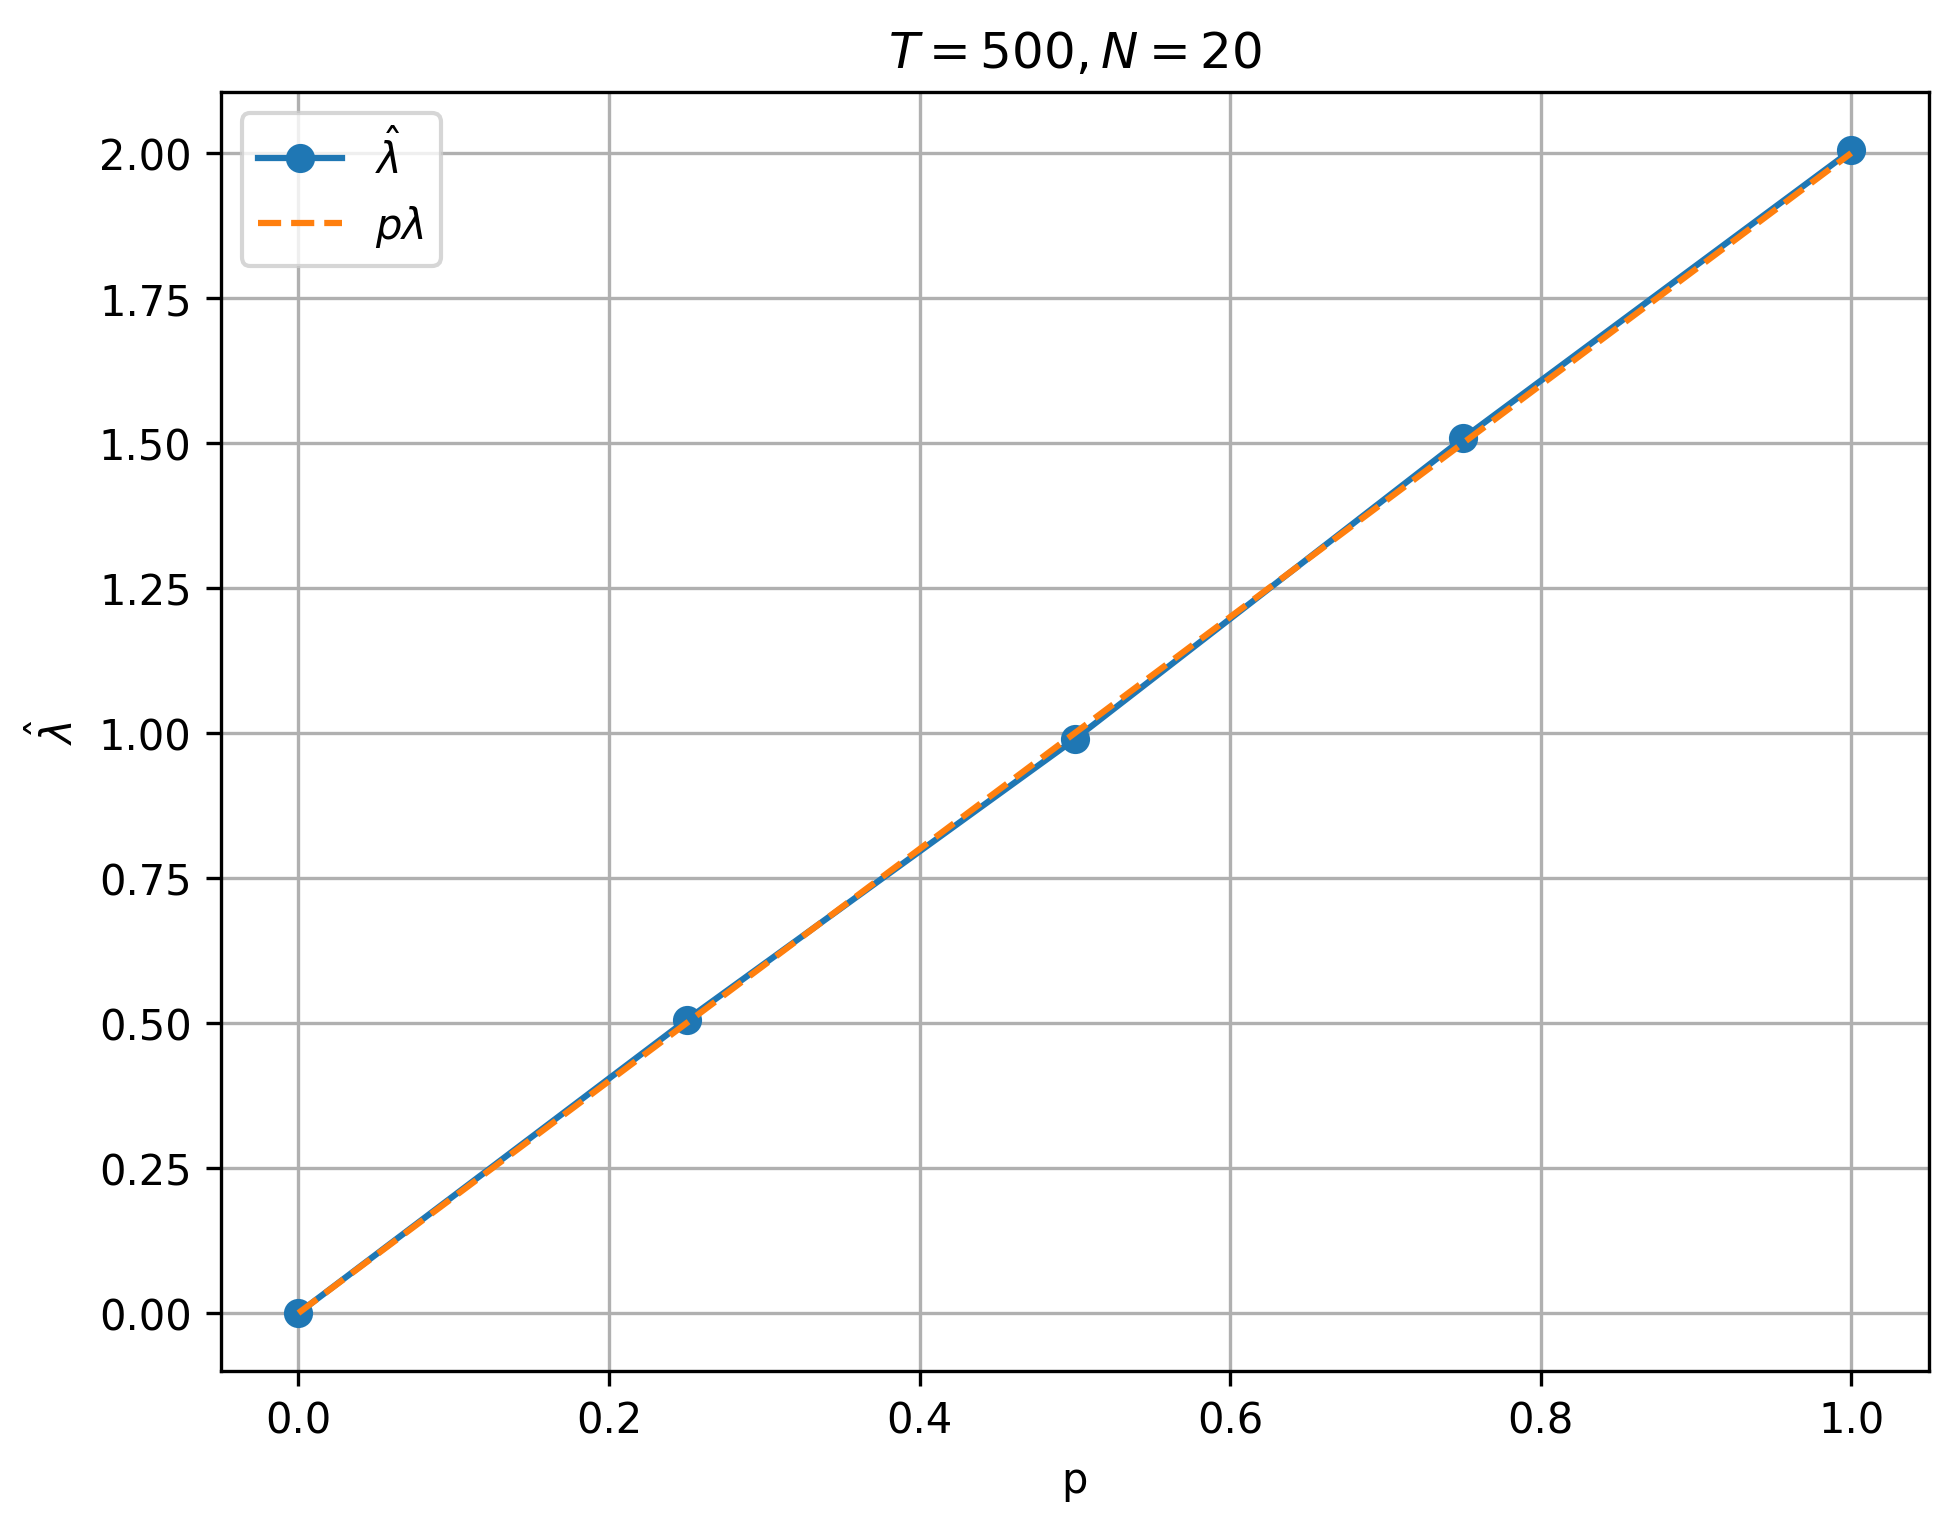

In [66]:
plt.plot(x, y, label=r'$\hat{\lambda}$', marker='o')
plt.plot(x, x * 2, linestyle='--', label=r'$p\lambda$')
plt.tight_layout()
plt.legend()
plt.xlabel('p')
plt.ylabel(r"$\hat{\lambda}$")
plt.title(r"$T=500, N=20$")
plt.grid(True)